# 10 — Profitability Dashboard
Four-panel profit margin overview: by category, customer segment, region, and monthly trend.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("10 — Profitability Dashboard")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 17:03:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ready.


## Query

In [2]:
cat_m = spark.sql('''
    SELECT p.category,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100,2) AS margin_pct,
           ROUND(SUM(oi.profit),2) AS total_profit
    FROM order_items oi JOIN products p ON oi.product_id=p.product_id WHERE oi.sales>0
    GROUP BY p.category ORDER BY margin_pct DESC
''').toPandas()

seg_m = spark.sql('''
    SELECT c.segment,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100,2) AS margin_pct,
           ROUND(SUM(oi.profit),2) AS total_profit
    FROM customers c
    JOIN orders o ON c.customer_id=o.customer_id
    JOIN order_items oi ON o.order_id=oi.order_id WHERE oi.sales>0
    GROUP BY c.segment ORDER BY margin_pct DESC
''').toPandas()

reg_m = spark.sql('''
    SELECT l.region,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100,2) AS margin_pct,
           ROUND(SUM(oi.profit),2) AS total_profit
    FROM orders o
    JOIN order_items oi ON o.order_id=oi.order_id
    JOIN locations   l  ON o.postal_code=l.postal_code WHERE oi.sales>0
    GROUP BY l.region ORDER BY margin_pct DESC
''').toPandas()

mon_m = spark.sql('''
    SELECT DATE_FORMAT(TO_DATE(o.order_date,"M/d/yyyy"),"yyyy-MM") AS month,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100,2) AS margin_pct
    FROM orders o JOIN order_items oi ON o.order_id=oi.order_id WHERE oi.sales>0
    GROUP BY month ORDER BY month
''').toPandas()
print(cat_m)

                              category  margin_pct  total_profit
0                        5 1/2"" X 4""       47.00         24.14
1              Cool White Energy Saver       46.69       1260.22
2                       5 1/2"" X 4"""       46.00        123.51
3                        300/Messages"       45.84         60.92
4                        25 Env./Pack"       45.44         22.71
5                        100 Messages"       45.27        127.60
6                               Canary       45.06         31.63
7                             100/Box"       44.27        503.31
8                   600 Sets per Book"       44.21        109.02
9                                Ream"       43.44        312.61
10                        Gregg Ruled"       43.39         62.85
11          24 Cards/25 Envelopes/Set"       42.17         71.04
12                   3 Forms per Page"       41.49         44.99
13                  One Form per Page"       41.18         10.39
14                       

## Visualisation

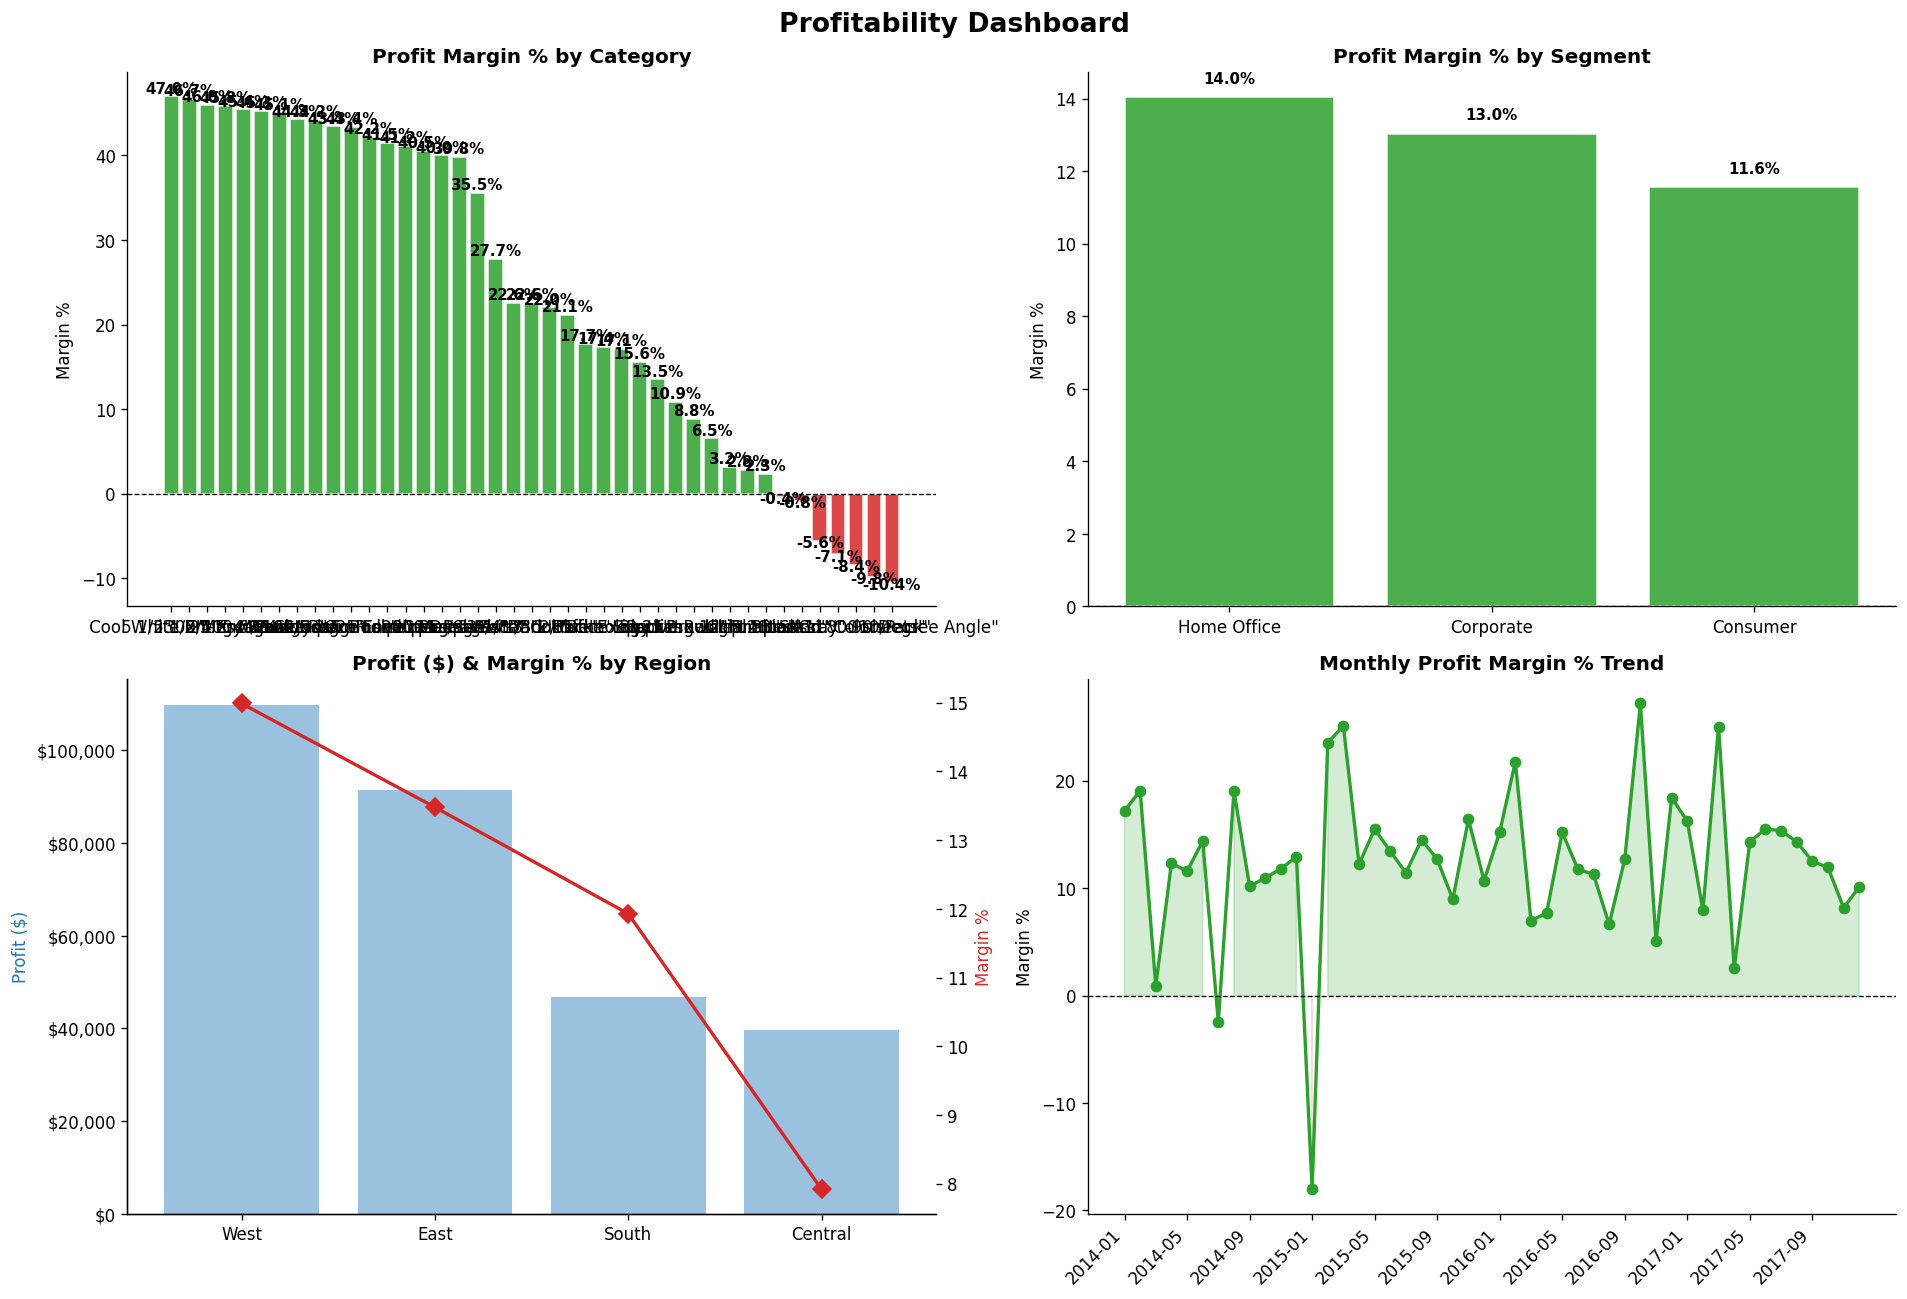

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/10_profitability_dashboard.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

def bar_margin(ax, labels, vals, title):
    c = ["#2ca02c" if v >= 0 else "#d62728" for v in vals]
    ax.bar(labels, vals, color=c, alpha=0.85, edgecolor="white")
    for i,(l,v) in enumerate(zip(labels, vals)):
        ax.text(i, v + (0.4 if v >= 0 else -0.8), f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("Margin %")

bar_margin(axes[0,0], cat_m["category"], cat_m["margin_pct"], "Profit Margin % by Category")
bar_margin(axes[0,1], seg_m["segment"],  seg_m["margin_pct"], "Profit Margin % by Segment")

reg_twin = axes[1,0].twinx()
axes[1,0].bar(reg_m["region"], reg_m["total_profit"], color="#1f77b4", alpha=0.45, label="Profit $")
reg_twin.plot(reg_m["region"], reg_m["margin_pct"], marker="D", color="#d62728", lw=2, ms=8, label="Margin %")
axes[1,0].set_title("Profit ($) & Margin % by Region", fontweight="bold")
axes[1,0].set_ylabel("Profit ($)", color="#1f77b4")
reg_twin.set_ylabel("Margin %", color="#d62728")
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

axes[1,1].plot(mon_m["month"], mon_m["margin_pct"], marker="o", color="#2ca02c", lw=2)
axes[1,1].fill_between(mon_m["month"], mon_m["margin_pct"],
                        where=[v >= 0 for v in mon_m["margin_pct"]], alpha=0.2, color="#2ca02c")
axes[1,1].fill_between(mon_m["month"], mon_m["margin_pct"],
                        where=[v < 0  for v in mon_m["margin_pct"]], alpha=0.2, color="#d62728")
axes[1,1].axhline(0, color="black", lw=0.8, ls="--")
axes[1,1].set_title("Monthly Profit Margin % Trend", fontweight="bold"); axes[1,1].set_ylabel("Margin %")
step = max(1, len(mon_m)//10)
axes[1,1].set_xticks(range(0,len(mon_m),step))
axes[1,1].set_xticklabels(mon_m["month"].iloc[::step], rotation=45, ha="right")

plt.suptitle("Profitability Dashboard", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/10_profitability_dashboard.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/10_profitability_dashboard.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
